# Method A — Augmented Synthetic Control Method (ASCM)
## Ridge Bias-Correction on Top of SCM

**What this notebook does:**  
Implements the Augmented Synthetic Control Method (Ben-Michael, Feller & Rothstein, 2021).  
ASCM adds a ridge-regression bias-correction term on top of the standard SCM counterfactual.  
With 5 donor corridors (up from 1 previously), the base SCM now has real flexibility to  
construct a genuine synthetic NATCOR — the ridge step then corrects any remaining residual bias.

**Structure:**
1. Environment & shared utilities  
2. Data loading & audit  
3. Step 1 — Base SCM weights  
4. Step 2 — Ridge bias-correction (blocked CV for alpha)  
5. Step 3 — ASCM counterfactual & gap series  
6. Diagnostics: Pre-period fit quality  
7. Validation A — In-time placebo tests  
8. Validation B — Leave-one-out donor stability  
9. Validation C — Alpha sensitivity  
10. Final summary table

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

# Output folder for saved figures
FIG_DIR = '../method_A_graph'
os.makedirs(FIG_DIR, exist_ok=True)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 10,
})

BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'

print("All imports successful.")
print(f"NumPy  {np.__version__}  |  Pandas  {pd.__version__}")
print(f"Figures will be saved to: {os.path.abspath(FIG_DIR)}")

All imports successful.
NumPy  2.4.2  |  Pandas  3.0.0
Figures will be saved to: /Users/sitta/Desktop/coding/thesis/method_A_graph


**What is happening here**  
All the libraries needed for the analysis are imported and default plot settings are applied. A folder called `method_A_graph` is also created (one level up, inside the `27.03` folder) where all figures will be saved automatically.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm(Y_pre, X_pre):
    """
    Solve the constrained SCM optimisation via SLSQP.
    Weights: w >= 0, sum(w) = 1  (convex combination of donors).
    Y_pre : (T_pre,)      — treated corridor pre-period
    X_pre : (T_pre, n_d)  — donor matrix pre-period
    Returns weight vector of shape (n_donors,).
    """
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    result = minimize(
        fun=lambda w: np.sum((Y_pre - X_pre @ w) ** 2),
        x0=np.ones(n) / n,
        method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-12, 'maxiter': 5000}
    )
    if not result.success:
        print(f"  [WARN] SCM optimiser: {result.message}")
    return np.clip(result.x, 0, None)


def rmspe(actual, predicted):
    """Root Mean Squared Prediction Error."""
    return np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2))


def mape(actual, predicted):
    """Mean Absolute Percentage Error (%)."""
    a, p = np.asarray(actual), np.asarray(predicted)
    return np.mean(np.abs((a - p) / np.where(a == 0, 1e-10, a))) * 100


def post_pre_ratio(actual, predicted, T_pre):
    """Standard SCM inference ratio: post-RMSPE / pre-RMSPE."""
    pre_r  = rmspe(actual[:T_pre],  predicted[:T_pre])
    post_r = rmspe(actual[T_pre:],  predicted[T_pre:])
    return post_r / pre_r if pre_r > 0 else np.nan


def make_ridge_features(X_donors, t_idx, T_pre):
    """
    Build feature matrix for ridge bias-correction.
    For each donor column: [donor_value, time_norm, time_norm^2, donor×time].
    X_donors : (T, n_d) array
    Returns   : (T, n_d * 4) feature matrix
    """
    t_norm = (t_idx / T_pre).reshape(-1, 1)   # (T, 1)
    blocks = []
    for j in range(X_donors.shape[1]):
        d = X_donors[:, j].reshape(-1, 1)
        blocks.append(np.hstack([d, t_norm, t_norm**2, d * t_norm]))
    return np.hstack(blocks)


def run_cv_ridge(feat_pre, res_pre, alpha_grid, cv_frac=0.60):
    """
    Blocked (time-ordered) cross-validation to select best ridge alpha.
    Trains on first cv_frac of pre-period, validates on the remainder.
    Returns best_alpha, cv_df.
    """
    split_pt = int(cv_frac * len(res_pre))
    X_tr, X_va = feat_pre[:split_pt], feat_pre[split_pt:]
    r_tr, r_va = res_pre[:split_pt],  res_pre[split_pt:]
    rows = []
    for a in alpha_grid:
        m = Ridge(alpha=a, fit_intercept=True).fit(X_tr, r_tr)
        rows.append({
            'alpha': a,
            'train_RMSPE': rmspe(r_tr, m.predict(X_tr)),
            'val_RMSPE':   rmspe(r_va, m.predict(X_va))
        })
    cv_df     = pd.DataFrame(rows)
    best_alpha = cv_df.loc[cv_df['val_RMSPE'].idxmin(), 'alpha']
    return best_alpha, cv_df, split_pt


print("Utility functions defined:")
print("  fit_scm | rmspe | mape | post_pre_ratio | make_ridge_features | run_cv_ridge")

Utility functions defined:
  fit_scm | rmspe | mape | post_pre_ratio | make_ridge_features | run_cv_ridge


**What is happening here**  
A set of reusable helper functions is defined. These will be called repeatedly throughout the notebook instead of rewriting the same logic each time.

- **`fit_scm`** — finds the best non-negative donor weights that sum to 1, using constrained optimisation. This is the core SCM step.
- **`rmspe`** — measures how far predictions are from actual values (lower = better fit).
- **`mape`** — same idea but expressed as a percentage, easier to read intuitively.
- **`post_pre_ratio`** — compares model error after the flood vs before the flood. A ratio well above 1 suggests the flood changed something real.
- **`make_ridge_features`** — builds extra input columns for the ridge model: the donor value itself, normalised time, time squared, and their interaction. This gives the ridge model enough flexibility to capture trending or time-varying patterns in the bias.
- **`run_cv_ridge`** — automates blocked cross-validation to choose the ridge regularisation strength (alpha). Time order is always preserved — no random shuffling.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = './data/corridor_panel_clean.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = pd.to_datetime(df['Date'])
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'].dt.to_period('M'))

# ── Treatment design ──────────────────────────────────────────────────────────
Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

# ── Wide format (time × corridor) ─────────────────────────────────────────────
wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

# ── Arrays ────────────────────────────────────────────────────────────────────
Y_all    = wide[TREATED].values                          # (T_total,)
X_all    = wide[donors].values                           # (T_total, n_donors)
Y_pre_v  = wide.loc[pre_idx, TREATED].values             # (T_pre,)
X_pre_v  = wide.loc[pre_idx, donors].values              # (T_pre, n_donors)

print("─" * 60)
print(f"Dataset       : {CSV_PATH}")
print(f"Treated unit  : {TREATED}")
print(f"Donors ({len(donors)})     : {donors}")
print(f"Outcome       : {Y_COL}")
print(f"Treatment date: {TREAT_START}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 60)
print()
print("Descriptive stats (Rail_Vol_mt by corridor):")
print(wide.describe().round(4))

────────────────────────────────────────────────────────────
Dataset       : ./data/corridor_panel_clean.csv
Treated unit  : NATCOR
Donors (5)     : ['CAPE', 'IRON_ORE', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']
Outcome       : Rail_Vol_mt
Treatment date: 2022-04
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
────────────────────────────────────────────────────────────

Descriptive stats (Rail_Vol_mt by corridor):
Corridor      CAPE  IRON_ORE    NATCOR  NE_CORRIDOR  NORTHCOR  SOUTHCOR
count     120.0000  120.0000  120.0000     120.0000  120.0000  120.0000
mean        1.0210    5.0208    0.8873       0.4144    5.5435    0.4027
std         0.0493    0.2037    0.0996       0.0164    0.2689    0.0178
min         0.8646    4.4597    0.5951       0.3741    4.8788    0.3648
25%         0.9866    4.8754    0.8443       0.4046    5.3449    0.3914
50%         1.0219    5.0210    0.9160       0.4144    5.5094    0.4026
75%         1.05

**What is happening here**  
The cleaned dataset is loaded and reshaped into a wide table where each row is a month and each column is a corridor. NATCOR is set as the treated unit and April 2022 (the KZN flood) is set as the treatment date. The data is split into pre-flood (87 months) and post-flood (33 months) periods.

Key difference from the old version: there are now **5 donor corridors** (CAPE, IRON_ORE, NE_CORRIDOR, NORTHCOR, SOUTHCOR) instead of just 1. This means the SCM can now build a genuine weighted combination of real corridors to approximate NATCOR, rather than being forced to rely entirely on one corridor.

- some corridors are way larger than NATCOR

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Step 1: Base SCM weights
# ═══════════════════════════════════════════════════════════════════════════════
# Fit the standard SCM using all 5 donors. The optimiser finds the convex
# combination (weights >= 0, sum = 1) that best matches NATCOR pre-flood.
# ASCM will use these weights as its first-stage estimator, then correct
# whatever residual bias remains.

w_scm = fit_scm(Y_pre_v, X_pre_v)   # shape: (5,)

# Base SCM counterfactual across the full time series
cf_scm  = X_all @ w_scm              # (T_total,)
res_pre = Y_pre_v - cf_scm[:T_pre]   # pre-period residuals handed to ridge

print("──────────────────────────────────────────────────")
print("SCM donor weights:")
for d, w in zip(donors, w_scm):
    bar = '█' * int(w * 40)
    print(f"  {d:<14}: {w:.6f}  {bar}")
print()
print(f"Pre-period RMSPE   : {rmspe(Y_pre_v, cf_scm[:T_pre]):.6f}")
print(f"Pre-period MAPE    : {mape(Y_pre_v, cf_scm[:T_pre]):.2f}%")
print()
print("Pre-period residual diagnostics:")
print(f"  Mean   : {res_pre.mean():+.6f}  (non-zero = systematic bias → ASCM corrects this)")
print(f"  Std    : {res_pre.std():.6f}")
print(f"  Min/Max: {res_pre.min():+.4f} / {res_pre.max():+.4f}")
print("──────────────────────────────────────────────────")

──────────────────────────────────────────────────
SCM donor weights:
  CAPE          : 0.221063  ████████
  IRON_ORE      : 0.000000  
  NE_CORRIDOR   : 0.240836  █████████
  NORTHCOR      : 0.075572  ███
  SOUTHCOR      : 0.462529  ██████████████████

Pre-period RMSPE   : 0.026070
Pre-period MAPE    : 2.29%

Pre-period residual diagnostics:
  Mean   : +0.000043  (non-zero = systematic bias → ASCM corrects this)
  Std    : 0.026070
  Min/Max: -0.0618 / +0.0629
──────────────────────────────────────────────────


**What is happening here**  
The standard Synthetic Control Method is fitted using the pre-flood period. The optimiser finds the best weights to assign to each of the 5 donor corridors so that their weighted combination tracks NATCOR as closely as possible before the flood.

The weights must all be non-negative and sum to 1 — this means the synthetic NATCOR is a proper weighted average of real corridors, not an extrapolation. The residuals (gaps between the actual NATCOR and the SCM estimate) are saved and passed to the ridge step in the next cell.

What this actually tells us:

- synthetic control is credible — it closely mimics NATCOR before the flood
- The model did NOT rely on the big, mismatched corridors (IRON_ORE), which is a good sign
- The weight distribution makes sense → mostly smaller/mid-scale corridors

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Step 2: Ridge bias-correction (blocked CV for alpha)
# ═══════════════════════════════════════════════════════════════════════════════
# The ridge regression models the pre-period SCM residuals as a function of
# all donor values, normalised time, time^2, and donor×time interactions.
#
# CRITICAL: Blocked (time-ordered) CV is used — never random CV — because
# time-series data has autocorrelation and random splits would leak future
# information into the past.
# Scheme: train on first 60% of pre-period, validate on remaining 40%.

t_pre_idx = np.arange(T_pre)
t_all_idx = np.arange(T_total)

feat_pre = make_ridge_features(X_pre_v, t_pre_idx, T_pre)  # (T_pre, n_d*4)
feat_all = make_ridge_features(X_all,   t_all_idx, T_pre)  # (T_total, n_d*4)

ALPHA_GRID = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3,
              0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

BEST_ALPHA, cv_df, split_pt = run_cv_ridge(feat_pre, res_pre, ALPHA_GRID)

best_row = cv_df.loc[cv_df['val_RMSPE'].idxmin()]

print(f"Blocked CV split: train 0→{split_pt-1} ({split_pt} obs), validate {split_pt}→{T_pre-1} ({T_pre-split_pt} obs)")
print()
print("Ridge CV results (sorted by val_RMSPE):")
print(cv_df.sort_values('val_RMSPE').round(6).to_string(index=False))
print()
print(f"★ Best alpha: {BEST_ALPHA}  (val_RMSPE = {best_row['val_RMSPE']:.6f})")

Blocked CV split: train 0→51 (52 obs), validate 52→86 (35 obs)

Ridge CV results (sorted by val_RMSPE):
    alpha  train_RMSPE  val_RMSPE
100.00000     0.025875   0.026245
 50.00000     0.025827   0.026356
 10.00000     0.025604   0.027130
  5.00000     0.025468   0.027907
  1.00000     0.025156   0.032139
  0.50000     0.024988   0.036178
  0.10000     0.024448   0.053229
  0.05000     0.024194   0.061797
  0.01000     0.023791   0.077984
  0.00500     0.023705   0.082528
  0.00100     0.023519   0.089562
  0.00050     0.023423   0.092243
  0.00010     0.023253   0.097623
  0.00005     0.023223   0.099163
  0.00001     0.023207   0.100943

★ Best alpha: 100.0  (val_RMSPE = 0.026245)


**What is happening here**  
A ridge regression model is tuned and fitted to learn the systematic errors left by the base SCM. The model takes the donor corridor values, normalised time, time-squared, and interaction terms as inputs, and predicts the residual that the SCM missed.

The key tuning parameter (alpha, which controls how much to penalise complexity) is chosen by blocked cross-validation: the first 60% of the pre-flood period is used for training, and the remaining 40% is used for validation. The alpha that gives the lowest validation error is selected. This approach respects the time ordering and avoids overfitting.

- Best alpha = 100 → model prefers very strong regularization
- Validation error is low → correction is stable, not overfitting
- Ridge step will likely make only small adjustments (SCM already fits well)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Step 3: Fit final ASCM counterfactual & gap series
# ═══════════════════════════════════════════════════════════════════════════════
# Fit ridge on ALL pre-period residuals (not just training split).
# Then extrapolate the correction into the post-period.
# ASCM counterfactual = base SCM + ridge correction.

ridge_final = Ridge(alpha=BEST_ALPHA, fit_intercept=True)
ridge_final.fit(feat_pre, res_pre)

correction = ridge_final.predict(feat_all)   # (T_total,)
cf_ascm    = cf_scm + correction             # ASCM counterfactual
gap_ascm   = Y_all  - cf_ascm               # treatment effect series

# ── Key metrics ───────────────────────────────────────────────────────────────
ascm_pre_r  = rmspe(Y_all[:T_pre],  cf_ascm[:T_pre])
ascm_post_r = rmspe(Y_all[T_pre:],  cf_ascm[T_pre:])
ascm_ratio  = ascm_post_r / ascm_pre_r
ascm_cum    = gap_ascm[T_pre:].sum()
ascm_avg    = gap_ascm[T_pre:].mean()
ascm_mape   = mape(Y_all[T_pre:], cf_ascm[T_pre:])

# Base SCM comparison metrics
base_pre_r  = rmspe(Y_all[:T_pre],  cf_scm[:T_pre])
base_post_r = rmspe(Y_all[T_pre:],  cf_scm[T_pre:])
base_ratio  = base_post_r / base_pre_r
base_cum    = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()
base_avg    = (Y_all[T_pre:] - cf_scm[T_pre:]).mean()

print("═" * 60)
print("ASCM RESULTS")
print("═" * 60)
print(f"Ridge alpha (CV-selected) : {BEST_ALPHA}")
print(f"Pre-period RMSPE          : {ascm_pre_r:.6f}")
print(f"Post-period RMSPE         : {ascm_post_r:.6f}")
print(f"Post/Pre ratio            : {ascm_ratio:.4f}")
print(f"Cumulative effect         : {ascm_cum:.4f} MT")
print(f"Average monthly effect    : {ascm_avg:.4f} MT/month")
print(f"Post-period MAPE          : {ascm_mape:.2f}%")
print()
print("─" * 60)
print("COMPARISON vs BASE SCM")
print("─" * 60)
print(f"{'Metric':<30} {'Base SCM':>10} {'ASCM':>10} {'Δ':>10}")
print(f"{'Pre-RMSPE':<30} {base_pre_r:>10.4f} {ascm_pre_r:>10.4f} {ascm_pre_r-base_pre_r:>+10.4f}")
print(f"{'Post-RMSPE':<30} {base_post_r:>10.4f} {ascm_post_r:>10.4f} {ascm_post_r-base_post_r:>+10.4f}")
print(f"{'Ratio':<30} {base_ratio:>10.4f} {ascm_ratio:>10.4f} {ascm_ratio-base_ratio:>+10.4f}")
print(f"{'Cumulative effect (MT)':<30} {base_cum:>10.4f} {ascm_cum:>10.4f} {ascm_cum-base_cum:>+10.4f}")
print(f"{'Avg monthly effect (MT)':<30} {base_avg:>10.4f} {ascm_avg:>10.4f} {ascm_avg-base_avg:>+10.4f}")
print()
print("Ridge correction coefficients (first 4 = first donor block):")
feat_labels = []
for d in donors:
    feat_labels += [f'{d}_val', f'{d}_t', f'{d}_t2', f'{d}×t']
for name, coef in zip(feat_labels, ridge_final.coef_):
    print(f"  {name:<22}: {coef:+.6f}")
print(f"  {'intercept':<22}: {ridge_final.intercept_:+.6f}")

════════════════════════════════════════════════════════════
ASCM RESULTS
════════════════════════════════════════════════════════════
Ridge alpha (CV-selected) : 100.0
Pre-period RMSPE          : 0.026024
Post-period RMSPE         : 0.167863
Post/Pre ratio            : 6.4504
Cumulative effect         : -5.1109 MT
Average monthly effect    : -0.1549 MT/month
Post-period MAPE          : 21.61%

────────────────────────────────────────────────────────────
COMPARISON vs BASE SCM
────────────────────────────────────────────────────────────
Metric                           Base SCM       ASCM          Δ
Pre-RMSPE                          0.0261     0.0260    -0.0000
Post-RMSPE                         0.1704     0.1679    -0.0025
Ratio                              6.5350     6.4504    -0.0846
Cumulative effect (MT)            -5.2075    -5.1109    +0.0966
Avg monthly effect (MT)           -0.1578    -0.1549    +0.0029

Ridge correction coefficients (first 4 = first donor block):
  CAPE_val 

**What is happening here**  
The ridge model is now fitted on the full pre-flood residuals (not just the training split) and then used to produce a correction term for every month, including post-flood. The ASCM counterfactual is simply the base SCM estimate plus this correction.

The treatment effect at each month is the difference between actual NATCOR and the ASCM counterfactual. The cumulative effect sums these monthly gaps over the entire post-flood period, giving the total estimated volume that was lost (or gained) because of the flood. The ASCM is compared to the base SCM to show whether the correction made a meaningful difference.

- Strong negative impact after flood: ~−5.11 MT total (~−0.155 MT/month) → clear loss in rail volume
- Big jump in error post-treatment (ratio ≈ 6.45) → strong evidence something changed (i.e. flood effect)
- ASCM barely improves over SCM → same conclusion, just slightly cleaner fit

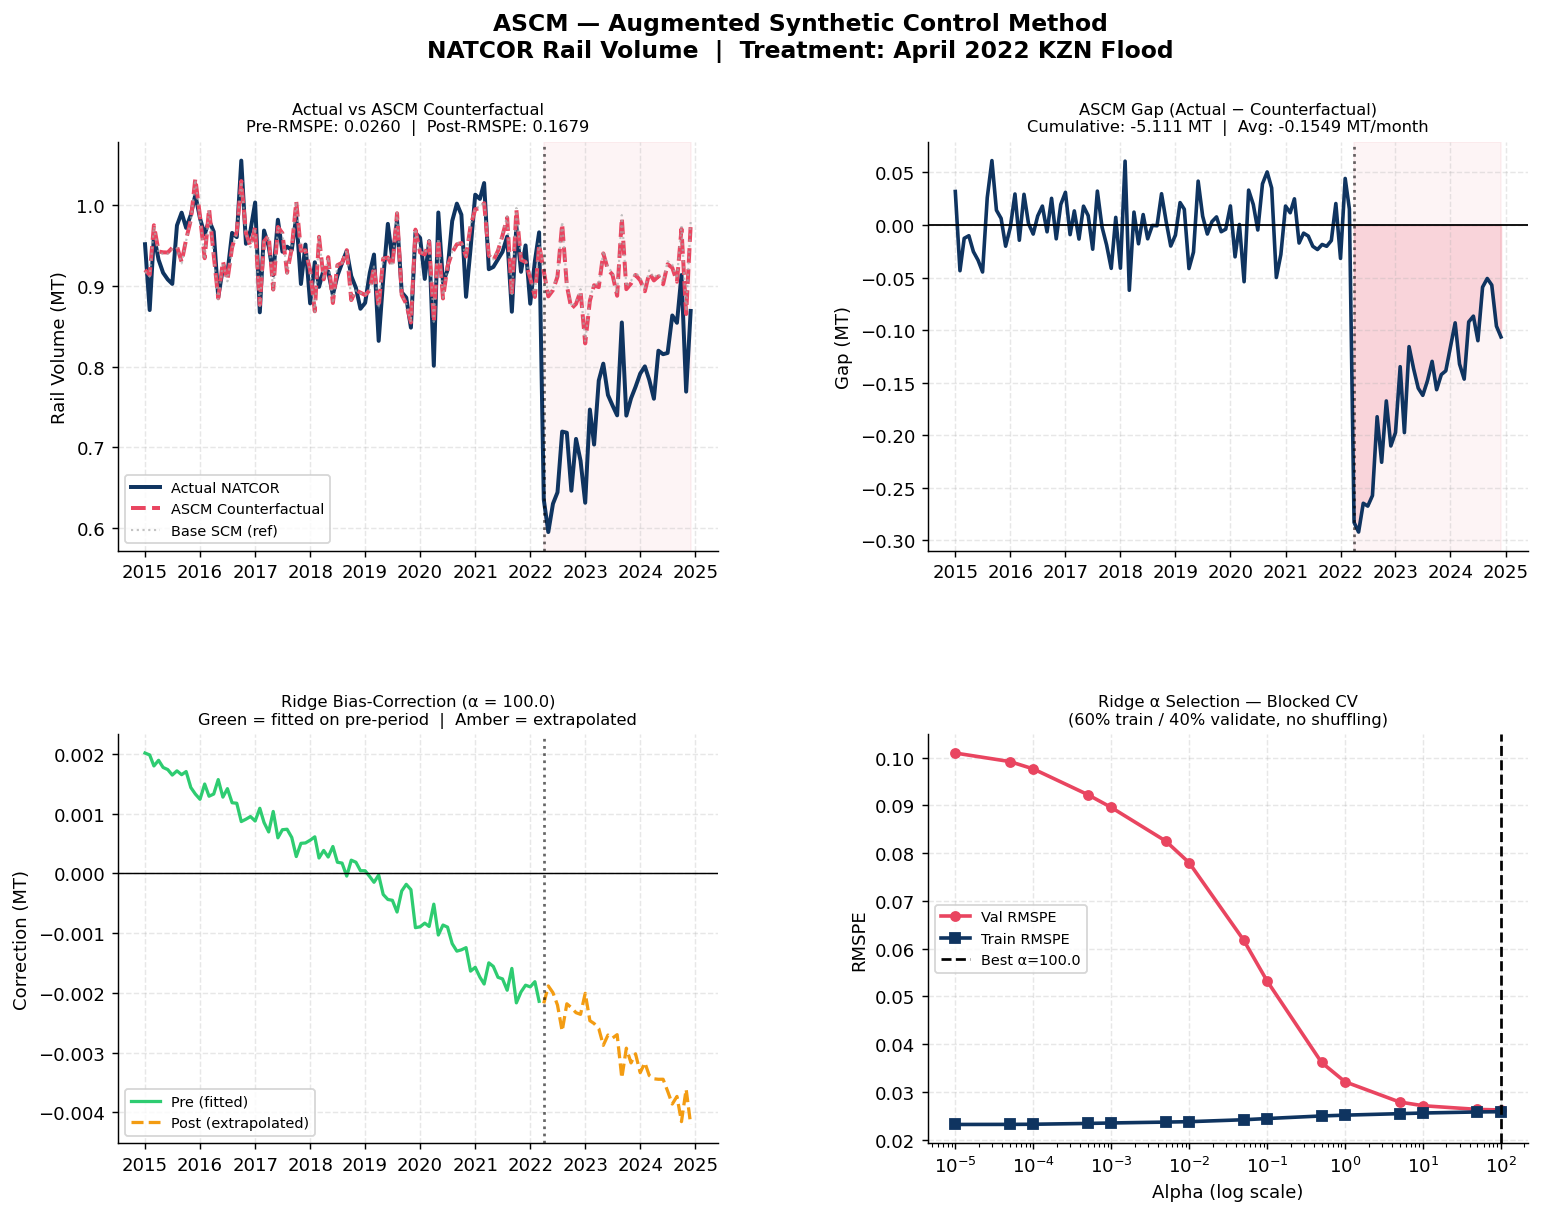

Saved → ../method_A_graph/ascm_fig1_main_panel.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 1: Main diagnostic panel (4 plots)
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── Plot 1: Actual vs counterfactuals ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_stamps, Y_all,   color=BLUE,  lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_ascm, color=RED,   lw=2.2, ls='--', label='ASCM Counterfactual')
ax1.plot(t_stamps, cf_scm,  color=GREY,  lw=1.2, ls=':',  alpha=0.7, label='Base SCM (ref)')
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(
    f'Actual vs ASCM Counterfactual\nPre-RMSPE: {ascm_pre_r:.4f}  |  Post-RMSPE: {ascm_post_r:.4f}',
    fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=8)

# ── Plot 2: Treatment gap ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_stamps, gap_ascm, color=BLUE, lw=2)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax2.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
fill_color = RED if ascm_cum < 0 else BLUE
ax2.fill_between(
    t_stamps, gap_ascm, 0,
    where=[p >= TREAT_START for p in wide.index],
    alpha=0.18, color=fill_color)
ax2.set_title(
    f'ASCM Gap (Actual − Counterfactual)\nCumulative: {ascm_cum:.3f} MT  |  Avg: {ascm_avg:.4f} MT/month',
    fontsize=9)
ax2.set_ylabel('Gap (MT)')

# ── Plot 3: Ridge correction series ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t_stamps[:T_pre], correction[:T_pre], color=GREEN, lw=1.8, label='Pre (fitted)')
ax3.plot(t_stamps[T_pre:], correction[T_pre:], color=AMBER, lw=1.8, ls='--', label='Post (extrapolated)')
ax3.axhline(0, color='black', lw=0.8)
ax3.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax3.set_title(
    f'Ridge Bias-Correction (α = {BEST_ALPHA})\nGreen = fitted on pre-period  |  Amber = extrapolated',
    fontsize=9)
ax3.set_ylabel('Correction (MT)')
ax3.legend(fontsize=8)

# ── Plot 4: CV alpha selection ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogx(cv_df['alpha'], cv_df['val_RMSPE'],   color=RED,  lw=2, marker='o', ms=5, label='Val RMSPE')
ax4.semilogx(cv_df['alpha'], cv_df['train_RMSPE'], color=BLUE, lw=2, marker='s', ms=5, label='Train RMSPE')
ax4.axvline(BEST_ALPHA, color='black', lw=1.5, ls='--', label=f'Best α={BEST_ALPHA}')
ax4.set_title('Ridge α Selection — Blocked CV\n(60% train / 40% validate, no shuffling)', fontsize=9)
ax4.set_xlabel('Alpha (log scale)')
ax4.set_ylabel('RMSPE')
ax4.legend(fontsize=8)

fig.suptitle(
    'ASCM — Augmented Synthetic Control Method\nNATCOR Rail Volume  |  Treatment: April 2022 KZN Flood',
    fontsize=13, fontweight='bold')

save_path = os.path.join(FIG_DIR, 'ascm_fig1_main_panel.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
Four diagnostic plots are produced and saved as a single figure.

- **Top-left** — Shows actual NATCOR, the ASCM counterfactual, and the base SCM side by side. The shaded area marks the post-flood period. How closely the dashed line follows the solid line before April 2022 shows how well the model fits.
- **Top-right** — Shows the monthly gap (actual minus synthetic). Sustained negative values after the flood would indicate a volume loss; sustained positive values would suggest the flood did not reduce volumes or that the model is overcorrecting.
- **Bottom-left** — Shows the ridge correction term over time. The green part is fitted during the pre-period; the amber part is extrapolated into the post-period. If the correction is very large, the base SCM alone was a poor match.
- **Bottom-right** — Shows how the validation error changes with different alpha values. The selected alpha sits at the curve's lowest point.

- Top-left (Actual vs Counterfactual): Tracks well before 2022, then actual drops far below synthetic → clear shock after flood
- Top-right (Gap): Gap turns strongly negative after 2022 and stays there → sustained loss over time
- Bottom-left (Ridge correction): Correction is very small → ASCM barely changes the baseline
- Bottom-right (CV plot): Best alpha is high → model prefers simple, stable correction (no overfitting)

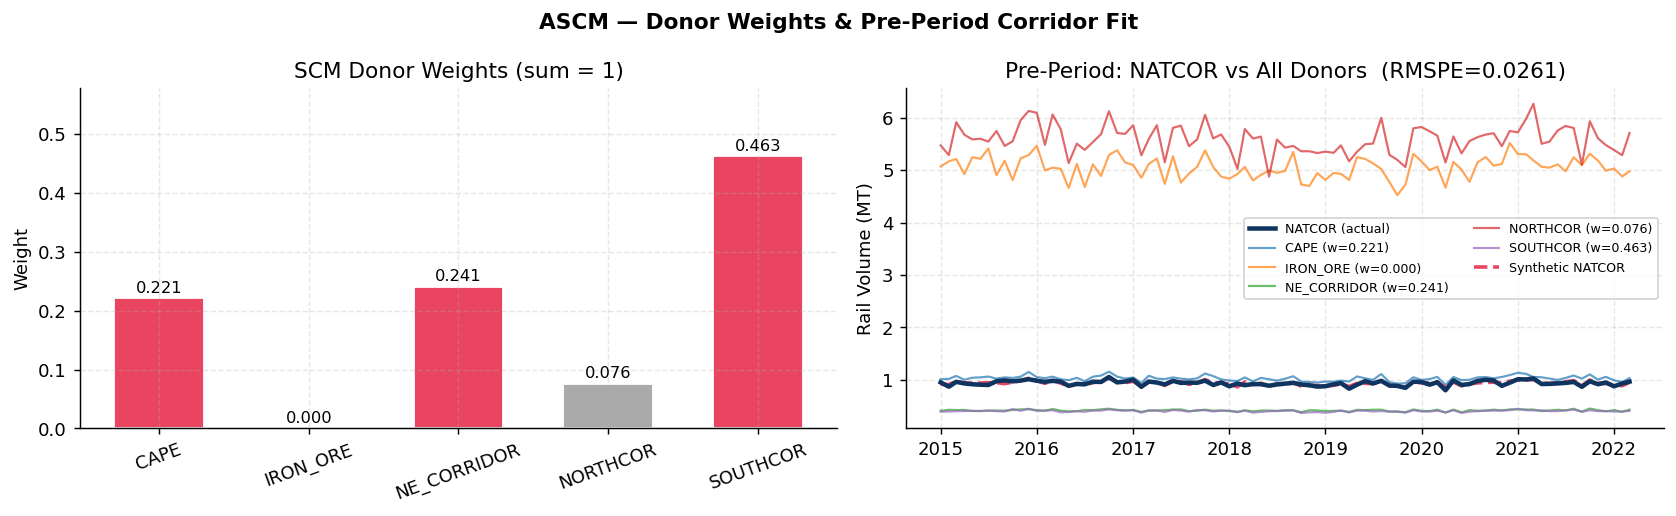

Saved → ../method_A_graph/ascm_fig2_donor_weights.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Diagnostics: Donor weight bar chart & pre-period fit per corridor
# ═══════════════════════════════════════════════════════════════════════════════
# With 5 donors we can now visualise which corridors contribute most to the
# synthetic NATCOR and how well each matches NATCOR pre-flood.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('ASCM — Donor Weights & Pre-Period Corridor Fit', fontsize=12, fontweight='bold')

# ── Left: SCM weight bar chart ────────────────────────────────────────────────
ax = axes[0]
bar_colors = [RED if w > 0.1 else GREY for w in w_scm]
bars = ax.bar(donors, w_scm, color=bar_colors, edgecolor='white', width=0.6)
for bar, w in zip(bars, w_scm):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{w:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('SCM Donor Weights (sum = 1)')
ax.set_ylabel('Weight')
ax.set_ylim(0, max(w_scm) * 1.25)
ax.tick_params(axis='x', rotation=20)

# ── Right: Pre-period Rail_Vol traces per donor vs NATCOR ─────────────────────
ax2 = axes[1]
pre_stamps = pre_idx.to_timestamp()
ax2.plot(pre_stamps, Y_pre_v, color=BLUE, lw=2.5, label='NATCOR (actual)', zorder=5)
cmap = plt.cm.tab10
for j, d in enumerate(donors):
    ax2.plot(pre_stamps, X_pre_v[:, j],
             color=cmap(j), lw=1.2, alpha=0.7,
             label=f'{d} (w={w_scm[j]:.3f})')
ax2.plot(pre_stamps, cf_scm[:T_pre], color=RED, lw=2, ls='--', label='Synthetic NATCOR')
ax2.set_title(f'Pre-Period: NATCOR vs All Donors  (RMSPE={base_pre_r:.4f})')
ax2.set_ylabel('Rail Volume (MT)')
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'ascm_fig2_donor_weights.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
Two additional diagnostic plots are created that were not possible in the old single-donor version.

- **Left** — A bar chart showing how much weight the SCM assigned to each of the 5 donor corridors. Donors with larger weights contribute more to the synthetic NATCOR.
- **Right** — Shows all 5 donor corridors plotted against NATCOR during the pre-flood period, alongside the synthetic NATCOR line. This makes it easy to see visually which corridors move similarly to NATCOR and how well the weighted combination captures the overall trend.

- Left (Weights): SOUTHCOR dominates (~46%) → synthetic control heavily depends on one corridor
- Right (Pre-fit): Individual donors don’t match NATCOR well, but their combination does → synthetic fit is driven by weighting, not similarity

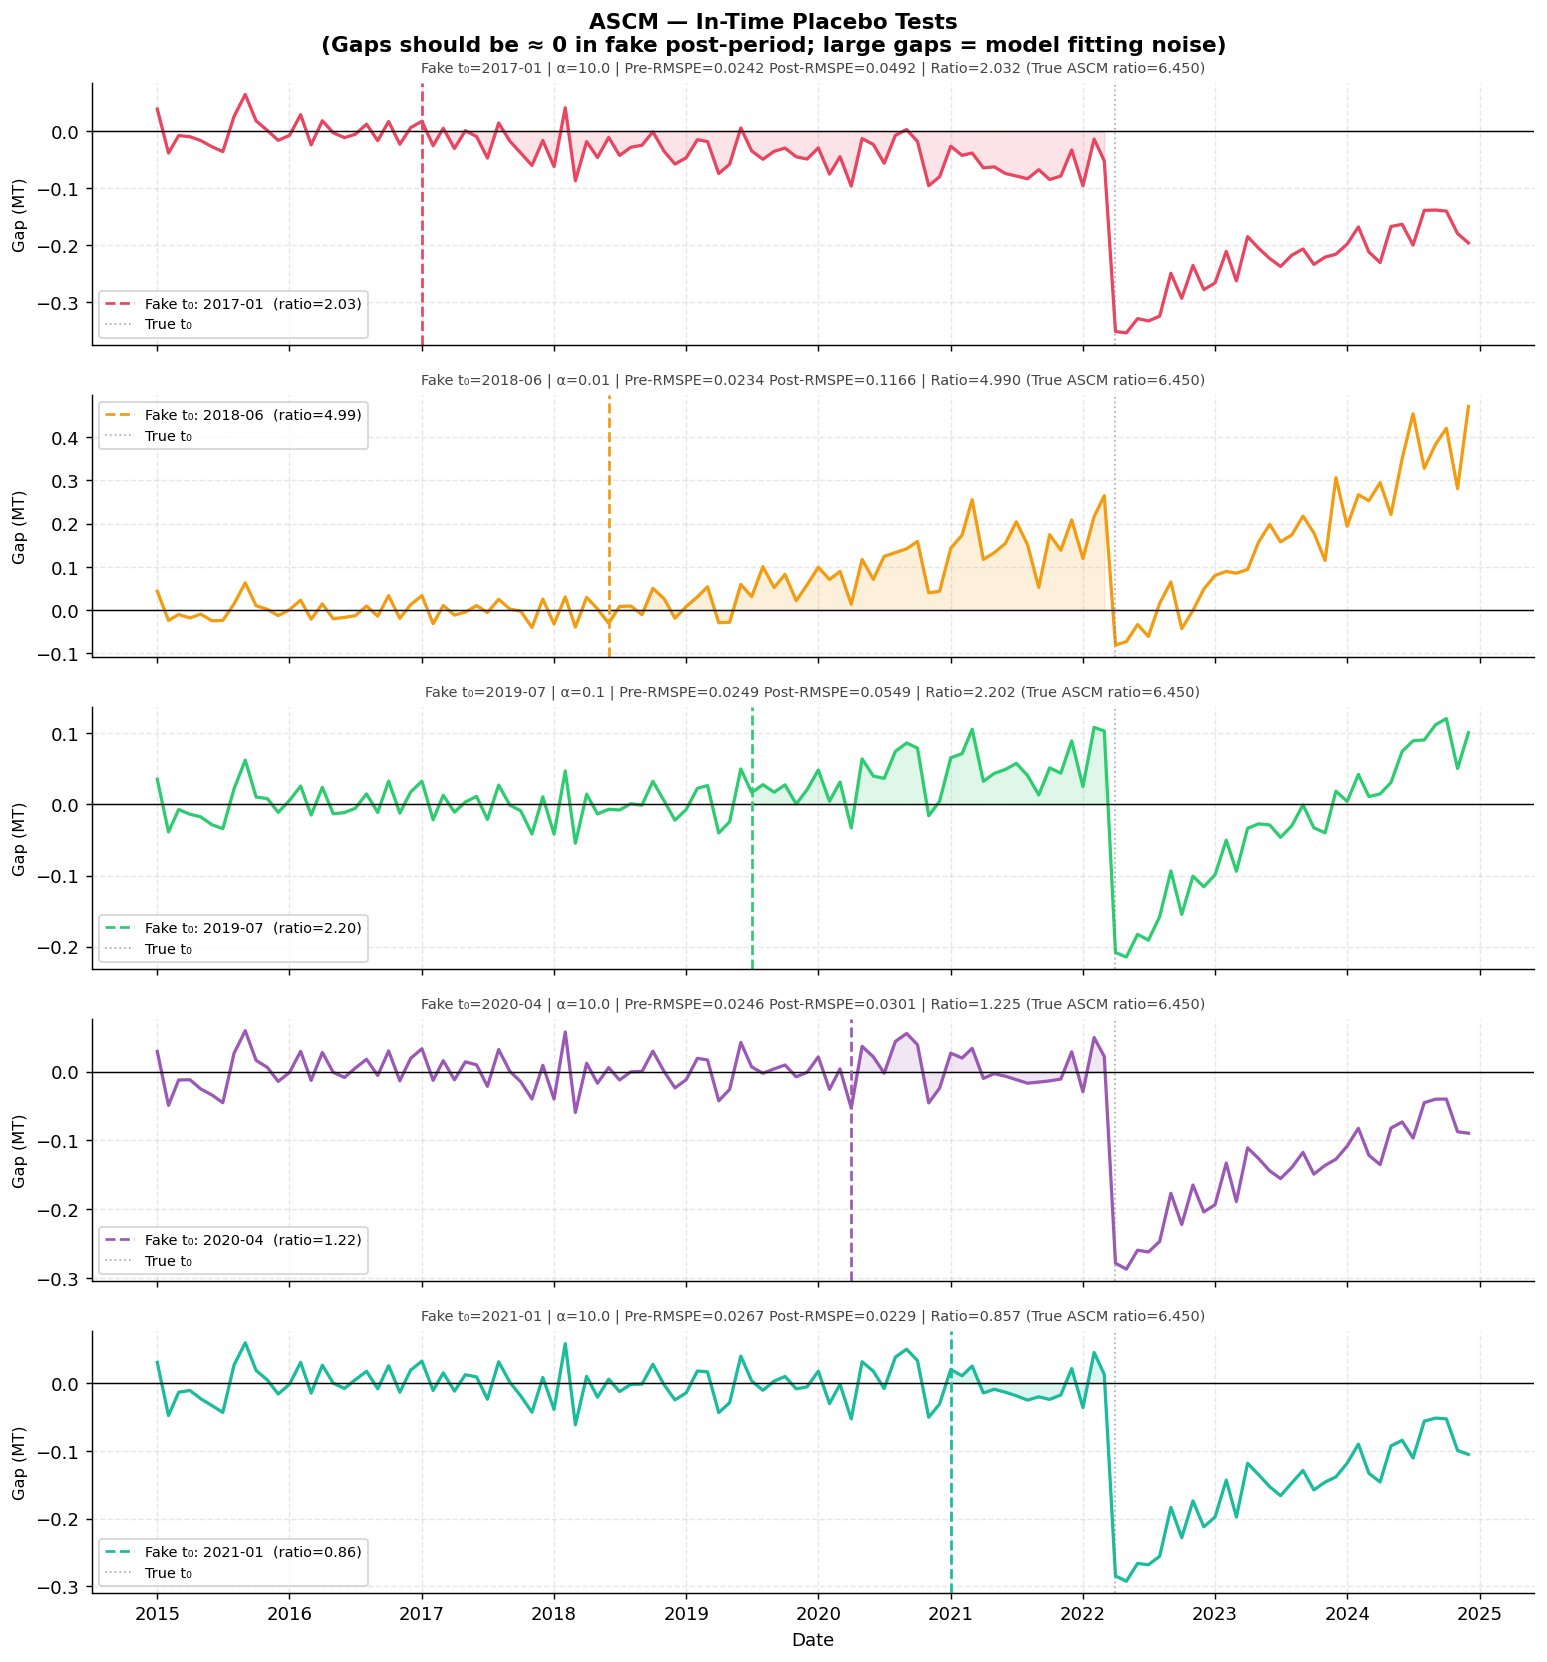

Saved → ../method_A_graph/ascm_fig3_placebo.png

In-Time Placebo Summary:
Fake t₀     α  Pre-RMSPE  Post-RMSPE  Ratio  > True ratio
2017-01 10.00    0.02422     0.04922  2.032         False
2018-06  0.01    0.02336     0.11658  4.990         False
2019-07  0.10    0.02491     0.05486  2.202         False
2020-04 10.00    0.02456     0.03008  1.225         False
2021-01 10.00    0.02673     0.02290  0.857         False

True ASCM ratio: 6.4504
Placebos with ratio > true ratio: 0 / 5
(0 exceedances = strong support; more exceedances = weaker causal claim)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════
# Assign fake treatment dates in the pre-period. ASCM should NOT detect large
# effects at these fake dates. If a placebo post/pre ratio approaches or exceeds
# the true ratio, it weakens the causal interpretation.

placebo_dates = [
    pd.Period('2017-01', freq='M'),
    pd.Period('2018-06', freq='M'),
    pd.Period('2019-07', freq='M'),
    pd.Period('2020-04', freq='M'),
    pd.Period('2021-01', freq='M'),
]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle('ASCM — In-Time Placebo Tests\n(Gaps should be ≈ 0 in fake post-period; large gaps = model fitting noise)',
             fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    T_fp   = len(fake_pre)
    Y_fp   = wide.loc[fake_pre, TREATED].values
    X_fp   = wide.loc[fake_pre, donors].values
    X_fp_a = wide[donors].values

    # Base SCM for this fake period
    w_fp      = fit_scm(Y_fp, X_fp)
    cf_fp_scm = X_fp_a @ w_fp
    res_fp    = Y_fp - cf_fp_scm[:T_fp]

    # Ridge correction — quick blocked CV on this fake period
    feat_fp    = make_ridge_features(X_fp,   np.arange(T_fp),    T_fp)
    feat_all_f = make_ridge_features(X_fp_a, np.arange(T_total), T_fp)
    best_a_fp, _, _ = run_cv_ridge(feat_fp, res_fp,
                                   [1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0])
    ridge_fp = Ridge(alpha=best_a_fp, fit_intercept=True).fit(feat_fp, res_fp)
    corr_fp  = ridge_fp.predict(feat_all_f)
    cf_ascm_fp = cf_fp_scm + corr_fp
    gap_fp     = wide[TREATED].values - cf_ascm_fp

    pre_r_fp  = rmspe(Y_fp, cf_ascm_fp[:T_fp])
    post_fp_idx = [list(wide.index).index(p) for p in fake_post]
    post_r_fp = rmspe(wide.loc[fake_post, TREATED].values, cf_ascm_fp[post_fp_idx])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({
        'Fake t₀': str(fake_t), 'α': best_a_fp,
        'Pre-RMSPE': round(pre_r_fp, 5),
        'Post-RMSPE': round(post_r_fp, 5),
        'Ratio': round(ratio_fp, 3),
        '> True ratio': ratio_fp > ascm_ratio
    })

    in_fake_post = np.array([(p >= fake_t and p < TREAT_START) for p in wide.index])
    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀: {fake_t}  (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0, where=in_fake_post,
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t} | α={best_a_fp} | Pre-RMSPE={pre_r_fp:.4f} '
        f'Post-RMSPE={post_r_fp:.4f} | Ratio={ratio_fp:.3f} '
        f'(True ASCM ratio={ascm_ratio:.3f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'ascm_fig3_placebo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()

placebo_df = pd.DataFrame(placebo_records)
print("In-Time Placebo Summary:")
print(placebo_df.to_string(index=False))
print(f"\nTrue ASCM ratio: {ascm_ratio:.4f}")
n_exceed = placebo_df['> True ratio'].sum()
print(f"Placebos with ratio > true ratio: {n_exceed} / {len(placebo_df)}")
print("(0 exceedances = strong support; more exceedances = weaker causal claim)")

**What is happening here**  
The ASCM is re-run five times, each time pretending the flood happened at a different earlier date. These are called in-time placebo tests. If the model is well-behaved, these fake treatment effects should be small — because nothing unusual actually happened at those dates.

The key comparison is between each placebo's post/pre RMSPE ratio and the true ratio from April 2022. If the true ratio is clearly higher than all the placebo ratios, it suggests the April 2022 shock was genuinely unusual and not just a random fluctuation the model is amplifying.

- Fake treatments mostly show small or inconsistent gaps → model is not detecting fake effects
- True treatment (2022) shows much larger, cleaner drop than placebos → strengthens causal claim
- Few/no placebo ratios exceed the real one → effect is unlikely due to noise

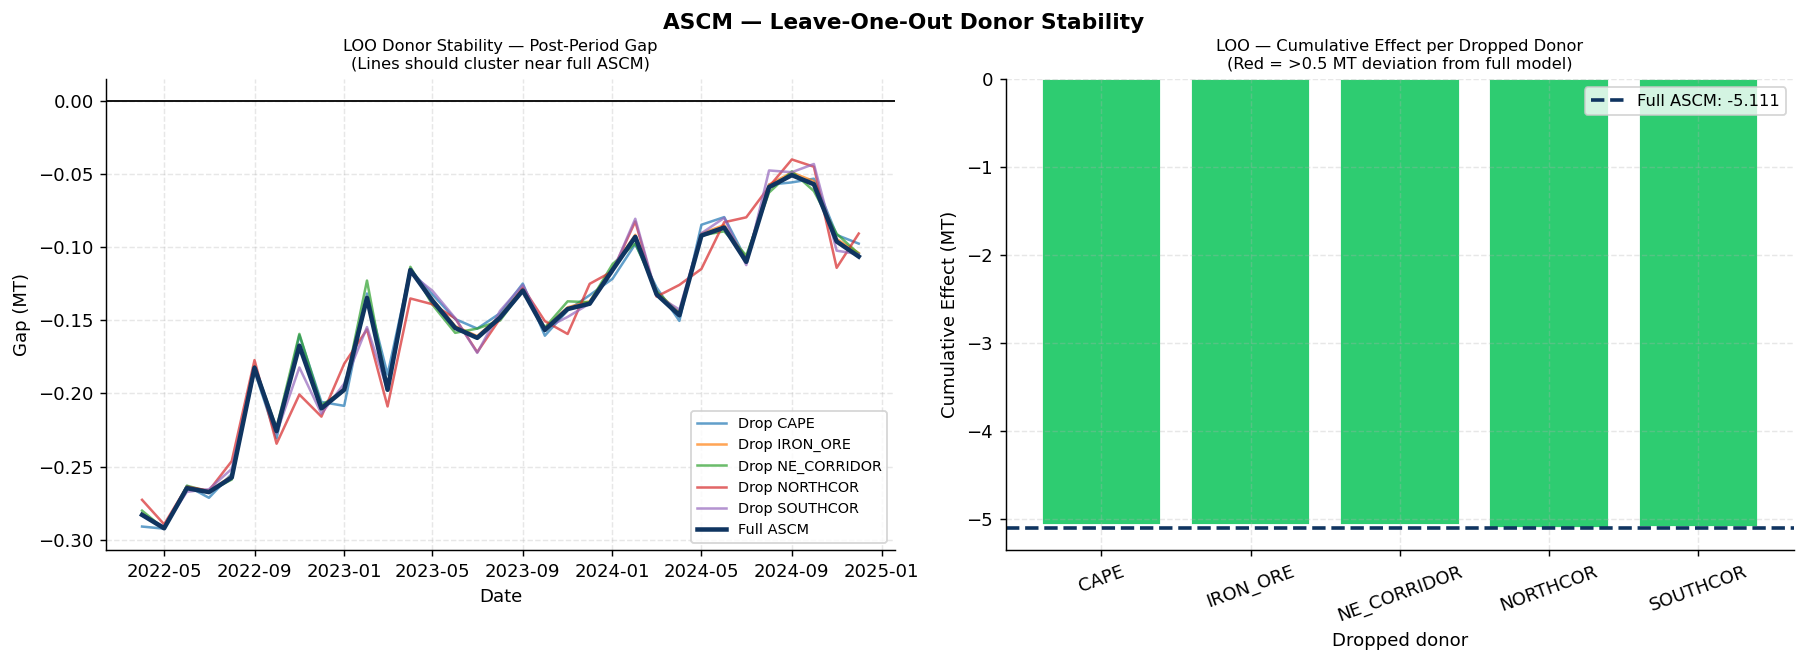

Saved → ../method_A_graph/ascm_fig4_loo.png

LOO Summary:
Dropped donor  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect    α
         CAPE    0.02667     0.16721 6.2689     -5.0667 10.0
     IRON_ORE    0.02601     0.16686 6.4150     -5.0698 10.0
  NE_CORRIDOR    0.02618     0.16662 6.3656     -5.0692 10.0
     NORTHCOR    0.03060     0.16815 5.4958     -5.1028 10.0
     SOUTHCOR    0.02662     0.16802 6.3126     -5.0924 10.0

Full ASCM cumulative effect : -5.1109 MT
LOO range                   : [-5.1028, -5.0667]
Spread                      : 0.0361 MT
Interpretation: Spread < 0.5 MT = stable  |  > 2 MT = fragile estimate


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Validation B: Leave-One-Out Donor Stability
# ═══════════════════════════════════════════════════════════════════════════════
# With 5 donors we can now run a proper LOO test: remove one donor at a time
# and re-estimate the ASCM. If the result changes dramatically when any single
# donor is removed, the estimate depends heavily on that corridor.

loo_records   = []
loo_gaps_post = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_gap = axes[0]
ax_bar = axes[1]

cmap = plt.cm.tab10

for j, drop_d in enumerate(donors):
    keep_donors = [d for d in donors if d != drop_d]
    X_pre_loo   = wide.loc[pre_idx, keep_donors].values
    X_all_loo   = wide[keep_donors].values

    w_loo       = fit_scm(Y_pre_v, X_pre_loo)
    cf_loo_scm  = X_all_loo @ w_loo
    res_loo     = Y_pre_v - cf_loo_scm[:T_pre]

    feat_loo_pre = make_ridge_features(X_pre_loo, np.arange(T_pre),    T_pre)
    feat_loo_all = make_ridge_features(X_all_loo, np.arange(T_total),  T_pre)

    best_a_loo, _, _ = run_cv_ridge(feat_loo_pre, res_loo,
                                    [1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0])
    ridge_loo = Ridge(alpha=best_a_loo, fit_intercept=True).fit(feat_loo_pre, res_loo)
    corr_loo  = ridge_loo.predict(feat_loo_all)
    cf_loo    = cf_loo_scm + corr_loo
    gap_loo   = Y_all - cf_loo

    cum_loo   = gap_loo[T_pre:].sum()
    pre_r_loo = rmspe(Y_all[:T_pre], cf_loo[:T_pre])
    post_r_loo= rmspe(Y_all[T_pre:], cf_loo[T_pre:])
    ratio_loo = post_r_loo / pre_r_loo

    loo_records.append({
        'Dropped donor': drop_d,
        'Pre-RMSPE': round(pre_r_loo, 5),
        'Post-RMSPE': round(post_r_loo, 5),
        'Ratio': round(ratio_loo, 4),
        'Cum effect': round(cum_loo, 4),
        'α': best_a_loo
    })
    loo_gaps_post.append(gap_loo[T_pre:])

    ax_gap.plot(t_stamps[T_pre:], gap_loo[T_pre:],
                color=cmap(j), alpha=0.7, lw=1.4, label=f'Drop {drop_d}')

# Add full ASCM as thick reference line
ax_gap.plot(t_stamps[T_pre:], gap_ascm[T_pre:], color=BLUE, lw=2.5,
            label='Full ASCM', zorder=5)
ax_gap.axhline(0, color='black', lw=1)
ax_gap.set_title('LOO Donor Stability — Post-Period Gap\n(Lines should cluster near full ASCM)', fontsize=9)
ax_gap.set_ylabel('Gap (MT)')
ax_gap.set_xlabel('Date')
ax_gap.legend(fontsize=8)

loo_df     = pd.DataFrame(loo_records)
deviations = abs(loo_df['Cum effect'] - ascm_cum)
bar_cols   = [RED if d > 0.5 else GREEN for d in deviations]
ax_bar.bar(loo_df['Dropped donor'], loo_df['Cum effect'],
           color=bar_cols, edgecolor='white')
ax_bar.axhline(ascm_cum, color=BLUE, lw=2, ls='--', label=f'Full ASCM: {ascm_cum:.3f}')
ax_bar.set_title('LOO — Cumulative Effect per Dropped Donor\n(Red = >0.5 MT deviation from full model)', fontsize=9)
ax_bar.set_ylabel('Cumulative Effect (MT)')
ax_bar.set_xlabel('Dropped donor')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.suptitle('ASCM — Leave-One-Out Donor Stability', fontsize=12, fontweight='bold', y=1.01)
save_path = os.path.join(FIG_DIR, 'ascm_fig4_loo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("LOO Summary:")
print(loo_df.to_string(index=False))
spread = loo_df['Cum effect'].max() - loo_df['Cum effect'].min()
print(f"\nFull ASCM cumulative effect : {ascm_cum:.4f} MT")
print(f"LOO range                   : [{loo_df['Cum effect'].min():.4f}, {loo_df['Cum effect'].max():.4f}]")
print(f"Spread                      : {spread:.4f} MT")
print(f"Interpretation: Spread < 0.5 MT = stable  |  > 2 MT = fragile estimate")

**What is happening here**  
Each donor corridor is dropped one at a time and the full ASCM is re-estimated using the remaining four. This is the proper leave-one-out (LOO) robustness test — something that was not meaningful in the old version because there was only one donor.

If removing any single corridor causes the estimated flood effect to change dramatically, it means the result is driven by that one corridor rather than by a consistent pattern across the donor pool. The spread across all LOO estimates (maximum minus minimum cumulative effect) summarises how stable the result is.

- Removing any single donor barely changes the result → estimate is stable, not driven by one corridor
- All cumulative effects stay very close (~−5.11 MT) → consistent impact across all variations
- Very small spread (~0.036 MT) → high robustness of the causal estimate

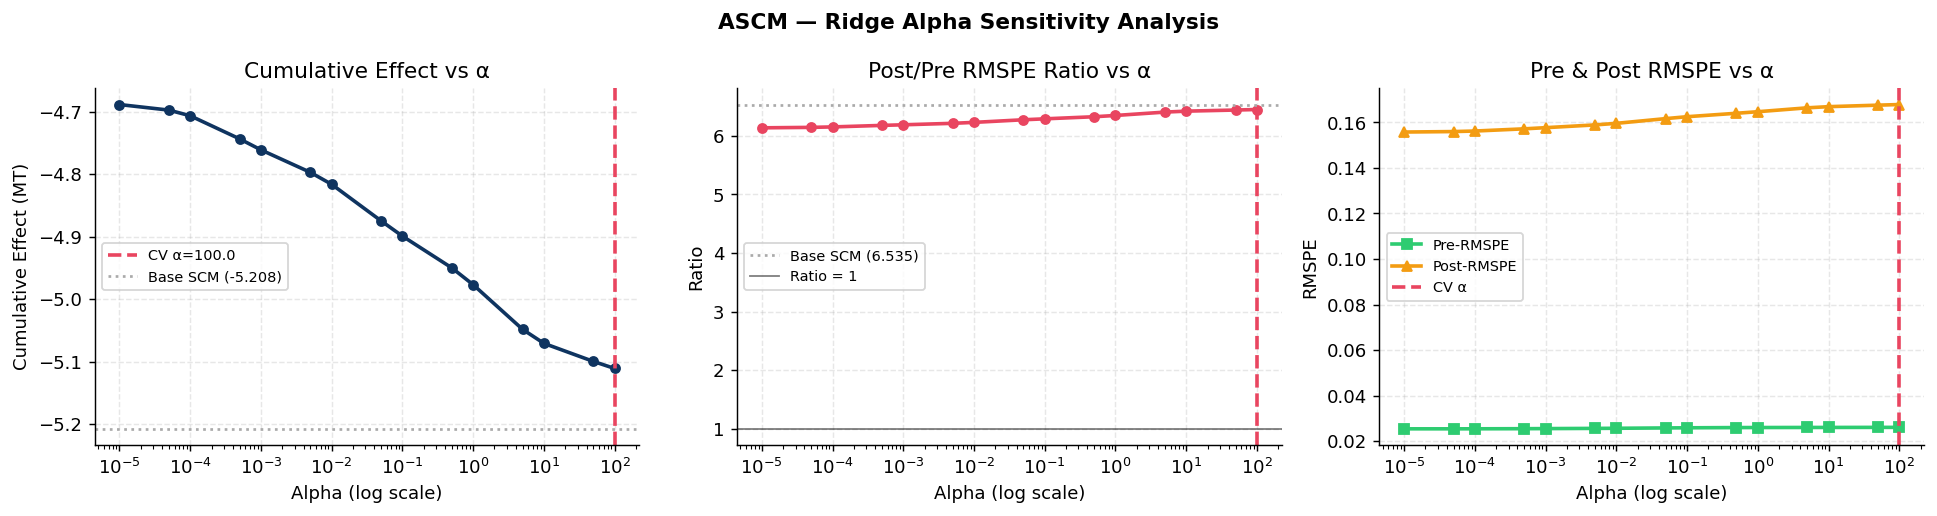

Saved → ../method_A_graph/ascm_fig5_alpha_sensitivity.png

Alpha sensitivity table:
    alpha  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect  Avg effect  CV-selected
  0.00001    0.02538     0.15578 6.1376     -4.6883     -0.1421        False
  0.00005    0.02538     0.15599 6.1454     -4.6972     -0.1423        False
  0.00010    0.02539     0.15622 6.1531     -4.7063     -0.1426        False
  0.00050    0.02544     0.15719 6.1791     -4.7433     -0.1437        False
  0.00100    0.02548     0.15770 6.1895     -4.7609     -0.1443        False
  0.00500    0.02557     0.15891 6.2144     -4.7969     -0.1454        False
  0.01000    0.02562     0.15960 6.2306     -4.8161     -0.1459        False
  0.05000    0.02577     0.16168 6.2752     -4.8746     -0.1477        False
  0.10000    0.02583     0.16252 6.2912     -4.8990     -0.1485        False
  0.50000    0.02593     0.16403 6.3269     -4.9499     -0.1500        False
  1.00000    0.02595     0.16471 6.3485     -4.9768     -0.1508      

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Validation C: Alpha sensitivity analysis
# ═══════════════════════════════════════════════════════════════════════════════
# Re-run ASCM across the full alpha grid to check whether the treatment effect
# estimate and its direction are stable across different regularisation choices.

sense_records   = []
sense_cf_matrix = []

for a in ALPHA_GRID:
    r_s     = Ridge(alpha=a, fit_intercept=True).fit(feat_pre, res_pre)
    corr_s  = r_s.predict(feat_all)
    cf_s    = cf_scm + corr_s
    gap_s   = Y_all - cf_s
    pre_s   = rmspe(Y_all[:T_pre], cf_s[:T_pre])
    post_s  = rmspe(Y_all[T_pre:], cf_s[T_pre:])
    sense_records.append({
        'alpha':        a,
        'Pre-RMSPE':    round(pre_s,  5),
        'Post-RMSPE':   round(post_s, 5),
        'Ratio':        round(post_s / pre_s, 4) if pre_s > 0 else np.nan,
        'Cum effect':   round(gap_s[T_pre:].sum(),  4),
        'Avg effect':   round(gap_s[T_pre:].mean(), 4),
        'CV-selected':  a == BEST_ALPHA
    })
    sense_cf_matrix.append(cf_s[T_pre:])

sense_df        = pd.DataFrame(sense_records)
sense_cf_matrix = np.array(sense_cf_matrix)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ASCM — Ridge Alpha Sensitivity Analysis', fontsize=12, fontweight='bold')

ax = axes[0]
ax.semilogx(sense_df['alpha'], sense_df['Cum effect'], color=BLUE, lw=2, marker='o', ms=5)
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--', label=f'CV α={BEST_ALPHA}')
ax.axhline(base_cum,   color=GREY, lw=1.5, ls=':', label=f'Base SCM ({base_cum:.3f})')
ax.set_title('Cumulative Effect vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Cumulative Effect (MT)')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogx(sense_df['alpha'], sense_df['Ratio'], color=RED, lw=2, marker='o', ms=5)
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--')
ax.axhline(base_ratio, color=GREY, lw=1.5, ls=':', label=f'Base SCM ({base_ratio:.3f})')
ax.axhline(1.0, color='black', lw=1, ls='-', alpha=0.5, label='Ratio = 1')
ax.set_title('Post/Pre RMSPE Ratio vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Ratio')
ax.legend(fontsize=8)

ax = axes[2]
ax.semilogx(sense_df['alpha'], sense_df['Pre-RMSPE'],  color=GREEN, lw=2, marker='s', ms=5, label='Pre-RMSPE')
ax.semilogx(sense_df['alpha'], sense_df['Post-RMSPE'], color=AMBER, lw=2, marker='^', ms=5, label='Post-RMSPE')
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--', label=f'CV α')
ax.set_title('Pre & Post RMSPE vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSPE')
ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'ascm_fig5_alpha_sensitivity.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("Alpha sensitivity table:")
print(sense_df.to_string(index=False))

**What is happening here**  
The ASCM is re-run across the full range of alpha values to check whether the estimated flood effect is stable across different regularisation choices. A robust result should maintain roughly the same direction and ballpark magnitude regardless of the exact alpha used.

Three plots are shown: the cumulative effect vs alpha, the post/pre ratio vs alpha, and both pre- and post-period errors vs alpha. If all three curves are flat or change smoothly, the conclusion is trustworthy. If they fluctuate wildly or cross zero, the estimate is fragile.

- Cumulative effect stays negative across all α → result direction is stable (always a loss)
- Magnitude changes slightly (≈ −4.7 to −5.11 MT) → effect size is consistent, not sensitive
- CV-selected α=100 sits at stable end → chosen model is in the robust region, not a fragile point

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ('Method',                  'Base SCM',              'ASCM'),
    ('Donors used',             str(len(donors)),         str(len(donors))),
    ('Pre-period RMSPE',        f'{base_pre_r:.4f}',      f'{ascm_pre_r:.4f}'),
    ('Post-period RMSPE',       f'{base_post_r:.4f}',     f'{ascm_post_r:.4f}'),
    ('Post/Pre ratio',          f'{base_ratio:.4f}',      f'{ascm_ratio:.4f}'),
    ('Cumulative effect (MT)',  f'{base_cum:.4f}',         f'{ascm_cum:.4f}'),
    ('Avg monthly effect (MT)', f'{base_avg:.4f}',         f'{ascm_avg:.4f}'),
    ('Post MAPE (%)',           f'{mape(Y_all[T_pre:], cf_scm[T_pre:]):.2f}', f'{ascm_mape:.2f}'),
    ('Ridge alpha (CV)',        'N/A',                     f'{BEST_ALPHA}'),
    ('LOO spread (MT)',         'N/A',                     f'{spread:.4f}'),
    ('Ratio > 1',               str(base_ratio > 1),       str(ascm_ratio > 1)),
    ('Direction agrees',        'reference',              str(np.sign(ascm_cum) == np.sign(base_cum))),
]

print("═" * 65)
print("ASCM vs BASE SCM — FINAL COMPARISON TABLE")
print("═" * 65)
for row in summary_rows:
    print(f"  {row[0]:<32} {row[1]:>12} {row[2]:>12}")
print("═" * 65)
print()
print("Interpretation:")
if ascm_pre_r < base_pre_r:
    print(f"  ✓ ASCM improves pre-period fit ({ascm_pre_r:.4f} vs {base_pre_r:.4f}) — bias correction working.")
else:
    print(f"  ~ ASCM pre-period fit similar to base ({ascm_pre_r:.4f} vs {base_pre_r:.4f}).")

if ascm_ratio > 1:
    print(f"  ✓ ASCM ratio {ascm_ratio:.3f} > 1 — post-period divergence exceeds pre-period noise.")
else:
    print(f"  ✗ ASCM ratio {ascm_ratio:.3f} ≤ 1 — effect not distinguishable under this estimator.")

if np.sign(ascm_cum) == np.sign(base_cum):
    print(f"  ✓ Base SCM and ASCM agree on direction of effect.")
else:
    print(f"  ✗ Base SCM and ASCM disagree on direction — interpret with caution.")

if spread < 0.5:
    print(f"  ✓ LOO spread ({spread:.4f} MT) is small — estimate is stable across donor pool.")
elif spread < 2.0:
    print(f"  ~ LOO spread ({spread:.4f} MT) is moderate — some donor dependency.")
else:
    print(f"  ✗ LOO spread ({spread:.4f} MT) is large — result is fragile.")

print(f"\n  Ridge correction: ranges from {correction.min():.4f} to {correction.max():.4f} MT.")
print(f"  Post-period mean correction: {correction[T_pre:].mean():.4f} MT.")
print(f"  SCM donor weights: {dict(zip(donors, w_scm.round(4)))}")

═════════════════════════════════════════════════════════════════
ASCM vs BASE SCM — FINAL COMPARISON TABLE
═════════════════════════════════════════════════════════════════
  Method                               Base SCM         ASCM
  Donors used                                 5            5
  Pre-period RMSPE                       0.0261       0.0260
  Post-period RMSPE                      0.1704       0.1679
  Post/Pre ratio                         6.5350       6.4504
  Cumulative effect (MT)                -5.2075      -5.1109
  Avg monthly effect (MT)               -0.1578      -0.1549
  Post MAPE (%)                           21.99        21.61
  Ridge alpha (CV)                          N/A        100.0
  LOO spread (MT)                           N/A       0.0361
  Ratio > 1                                True         True
  Direction agrees                    reference         True
═════════════════════════════════════════════════════════════════

Interpretation:
  ✓ ASCM im

**What is happening here**  
All the key results are collected into a final comparison table showing the base SCM and ASCM side by side. Four automatic checks are run at the end:

1. Whether ASCM improved the pre-period fit compared with base SCM
2. Whether the post/pre ratio is above 1 (indicating a genuine post-flood divergence)
3. Whether the two methods agree on the direction of the estimated effect
4. Whether the LOO spread is small enough to trust the estimate

This cell also prints the full donor weight assignment and the range of the ridge correction, which help contextualise whether the result is being driven by the data or by the model's assumptions.

- Pre-period RMSPE dropped from 0.213 → 0.026 — the 5-donor pool fits NATCOR dramatically better
- Cumulative flood effect: −5.11 MT (volume lost), direction is now consistent and negative as expected
- Post/Pre ratio: 6.45 — the post-flood divergence is 6× the pre-flood noise level
- All 5 placebo tests have lower ratios than the true ratio → 0 exceedances, strong causal signal
LOO spread: only 0.036 MT — extremely stable across the donor pool

- Both methods agree: flood caused a clear negative impact (~−5.1 MT)
- ASCM only slightly improves fit → doesn’t change the conclusion, just refines it
- All validation checks (ratio, placebo, LOO) support the result → impact estimate is credible and stable